# Q2 - Code Review_Required Capstone_12.1

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.stats import norm

In [2]:
inputs2 = np.array([[0.66579958, 0.12396913],
       [0.87779099, 0.7786275 ],
       [0.14269907, 0.34900513],
       [0.84527543, 0.71112027],
       [0.45464714, 0.29045518],
       [0.57771284, 0.77197318],
       [0.43816606, 0.68501826],
       [0.34174959, 0.02869772],
       [0.33864816, 0.21386725],
       [0.70263656, 0.9265642 ],
       [0.727272, 0.939393],
       [0.840803, 0.130818],
       [0.691269, 0.924740],
       [0.797595, 0.931864]])

In [3]:
outputs2 = np.array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
        0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522, 0.507049598072218, 
        0.2627386914961054, 0.48461365245218785, 0.014073924510516311])

## Surrogate model

In [4]:
X = inputs2 
y = outputs2

#kernel_best_Q2 =  ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.5, nu=1) + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-6, 1e1))
kernel_best_Q2 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.5, length_scale_bounds=(1e-2, 1e2)) 

# Initialize Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel_best_Q2, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)

# Fit to data
gp.fit(X, y)

print("Optimized kernel:", gp.kernel_)

Optimized kernel: 0.943**2 * RBF(length_scale=0.0244)


## Scatter plot - observations (2D)

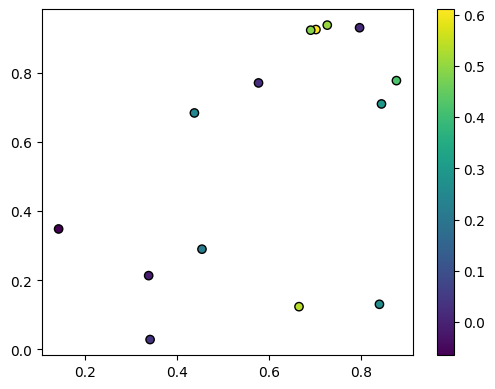

In [5]:
# Plot results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")

plt.colorbar()

plt.tight_layout()
plt.show()

## Scatter plot - observations (3D)

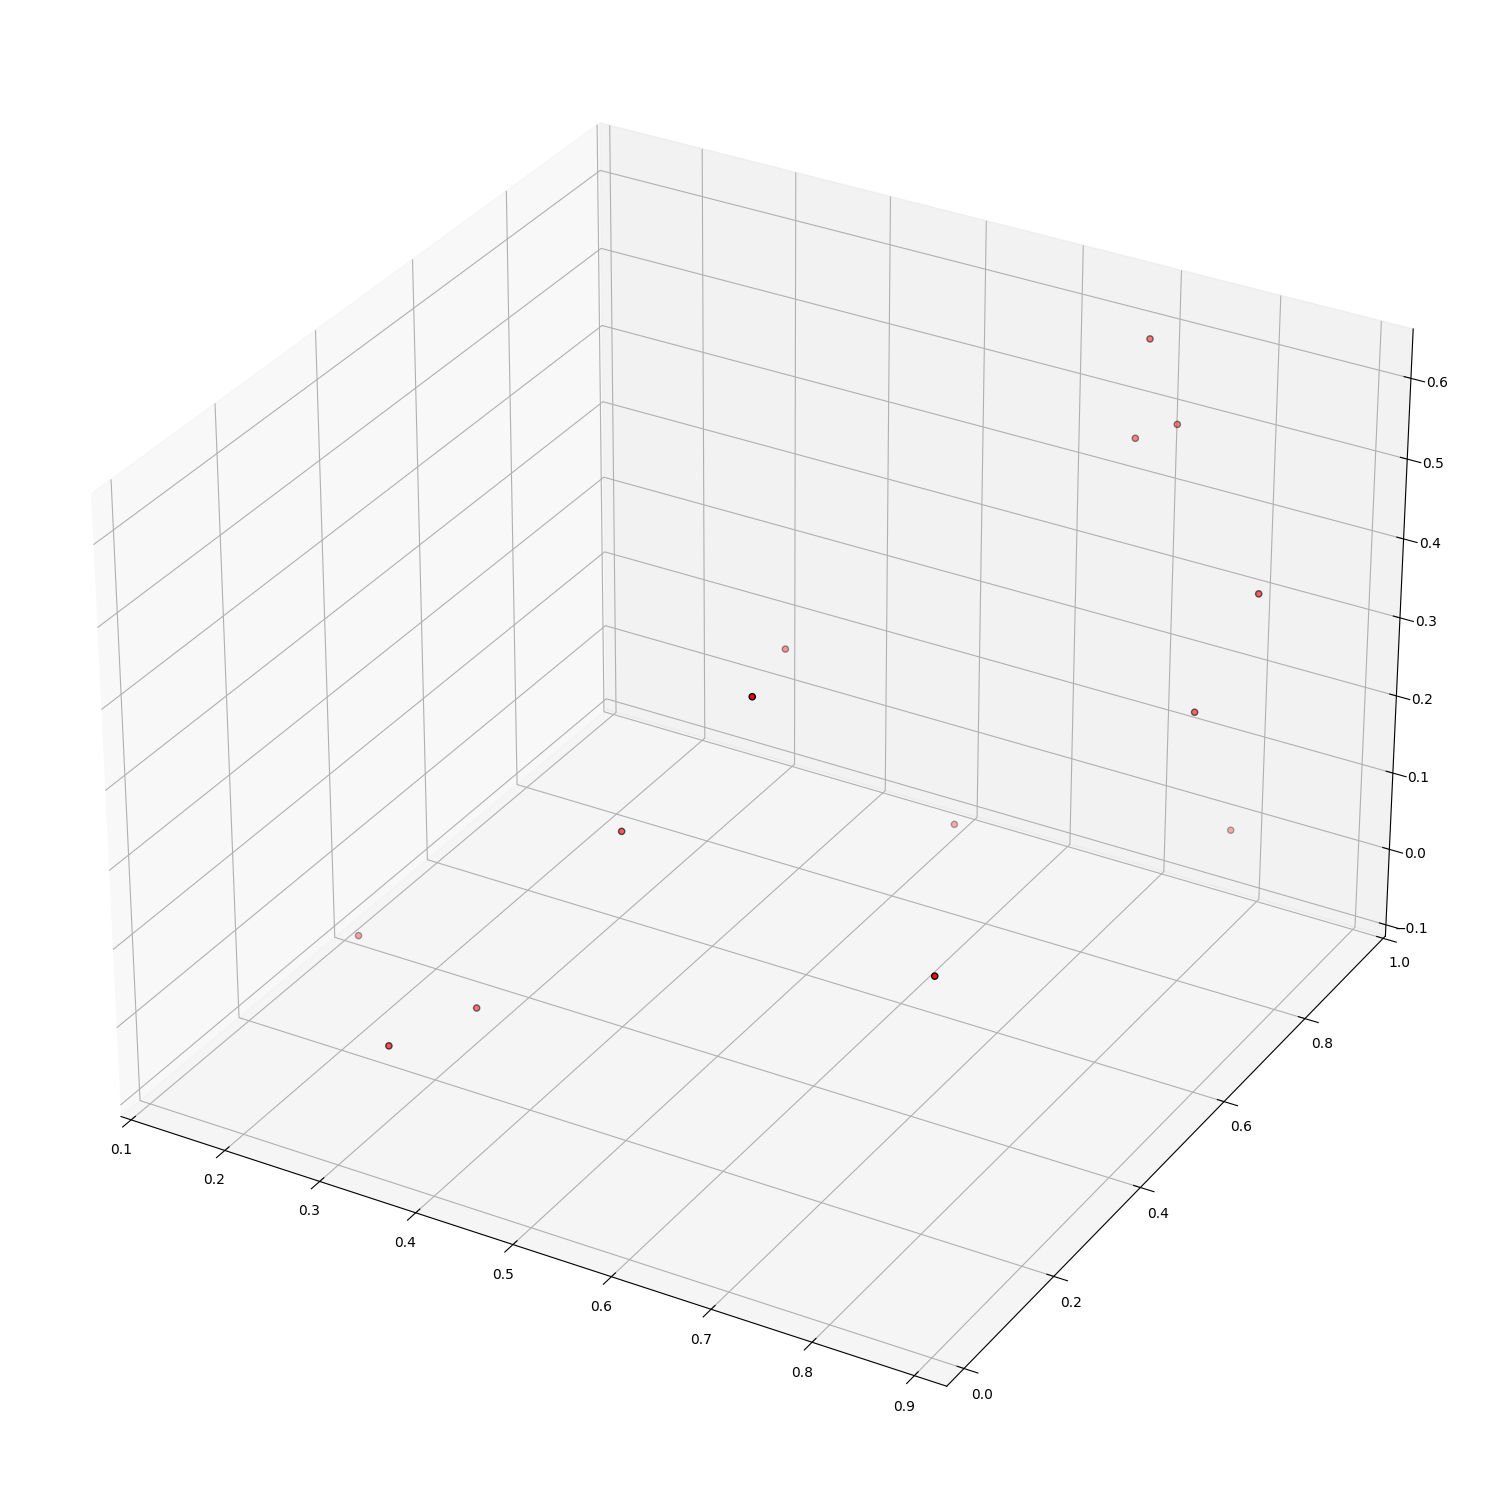

In [6]:
# Plot observations
fig = plt.figure(figsize=(20, 15))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, c = 'red', edgecolors="k")

plt.tight_layout()
plt.show()

## Acquistion function - Bayesian Optimization

In [7]:
def ucb(X_candidates, gp, kappa=2.0):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    return mu + kappa * sigma

def optimize_acquisition_global(acquisition_func, gp, bounds, kappa=4.0, maxiter=100, popsize=30):
    # Objective to minimize (negative because DE minimizes)
    def objective(x):
        x = np.array(x).reshape(1, -1)
        return -acquisition_func(x, gp, kappa=kappa)[0]

    # Differential Evolution global optimization
    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        polish=True,       # refine the result locally at the end
        disp=True           # print optimization progress
    )

    x_next = result.x
    best_val = -result.fun
    return x_next, best_val

In [8]:
bounds = [(0, 1), (0, 1)]

next_point1, best_val1 = optimize_acquisition_global(
        acquisition_func=ucb,
        gp=gp,
        bounds=bounds,
        kappa=2,      # larger kappa → more exploration
        maxiter=2000,     # number of DE iterations
        popsize=5000      # population size
    )

# Optimize acquisition
print("Next query point (by UCB):", next_point1)

differential_evolution step 1: f(x)= -0.8370069474739069
differential_evolution step 2: f(x)= -0.8370069474739069
differential_evolution step 3: f(x)= -0.8370069474739069
differential_evolution step 4: f(x)= -0.8370069474739069
differential_evolution step 5: f(x)= -0.8370365311144339
differential_evolution step 6: f(x)= -0.8376781412166039
differential_evolution step 7: f(x)= -0.8379550326995189
differential_evolution step 8: f(x)= -0.8379550326995189
differential_evolution step 9: f(x)= -0.8379571517722615
differential_evolution step 10: f(x)= -0.837970287490255
differential_evolution step 11: f(x)= -0.837970287490255
differential_evolution step 12: f(x)= -0.837970287490255
differential_evolution step 13: f(x)= -0.837970287490255
differential_evolution step 14: f(x)= -0.837970287490255
differential_evolution step 15: f(x)= -0.837982940889877
differential_evolution step 16: f(x)= -0.837982940889877
differential_evolution step 17: f(x)= -0.837982940889877
differential_evolution step 18:

## Acquisition function - Grid search (UCB)

In [9]:
def ucb_gs(X_candidates, gp, kappa=1.0):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    return mu + kappa * sigma
# ------------------------------
# Generate candidate points (dense grid in [0,1]^2)
# ------------------------------
x1_gs = np.linspace(0, 1, 500)
x2_gs = np.linspace(0, 1, 500)
X1_gs, X2_gs = np.meshgrid(x1_gs, x2_gs)
X_grid_gs = np.column_stack([X1_gs.ravel(), X2_gs.ravel()])

ucb_values_gs = ucb_gs(X_grid_gs, gp, kappa=1)

# Pick next query point (max UCB)
next_point_ucb_gs = X_grid_gs[np.argmax(ucb_values_gs)]
print("Next query point (by UCB):", next_point_ucb_gs)

Next query point (by UCB): [0.71543086 0.91783567]


## Acquisition function - Grid search (EI)

In [10]:
def expected_improvement_gs(X_cand, gp, y_best, xi=0.5):
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    imp = mu - y_best - xi
    
    with np.errstate(divide='ignore', invalid='ignore'):
         Z = imp / sigma
         ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
         ei[sigma.flatten() == 0.0] = 0.0
    return ei.ravel()

In [11]:
y_best = np.max(y)
acq_values = expected_improvement_gs(X_grid_gs, gp, y_best)

best_idx = np.argmax(acq_values)
next_point_ei_gs = X_grid_gs[best_idx]

print("Next suggested compound mix", next_point_ei_gs)
print("Predicted improvement score", acq_values[best_idx])

Next suggested compound mix [0.72344689 0.8997996 ]
Predicted improvement score 7.184686810250712e-06


## Predicted mean and standard deviation

In [12]:
y_mean, y_std = gp.predict(X_grid_gs, return_std=True)

## Contour plot - Predicted mean

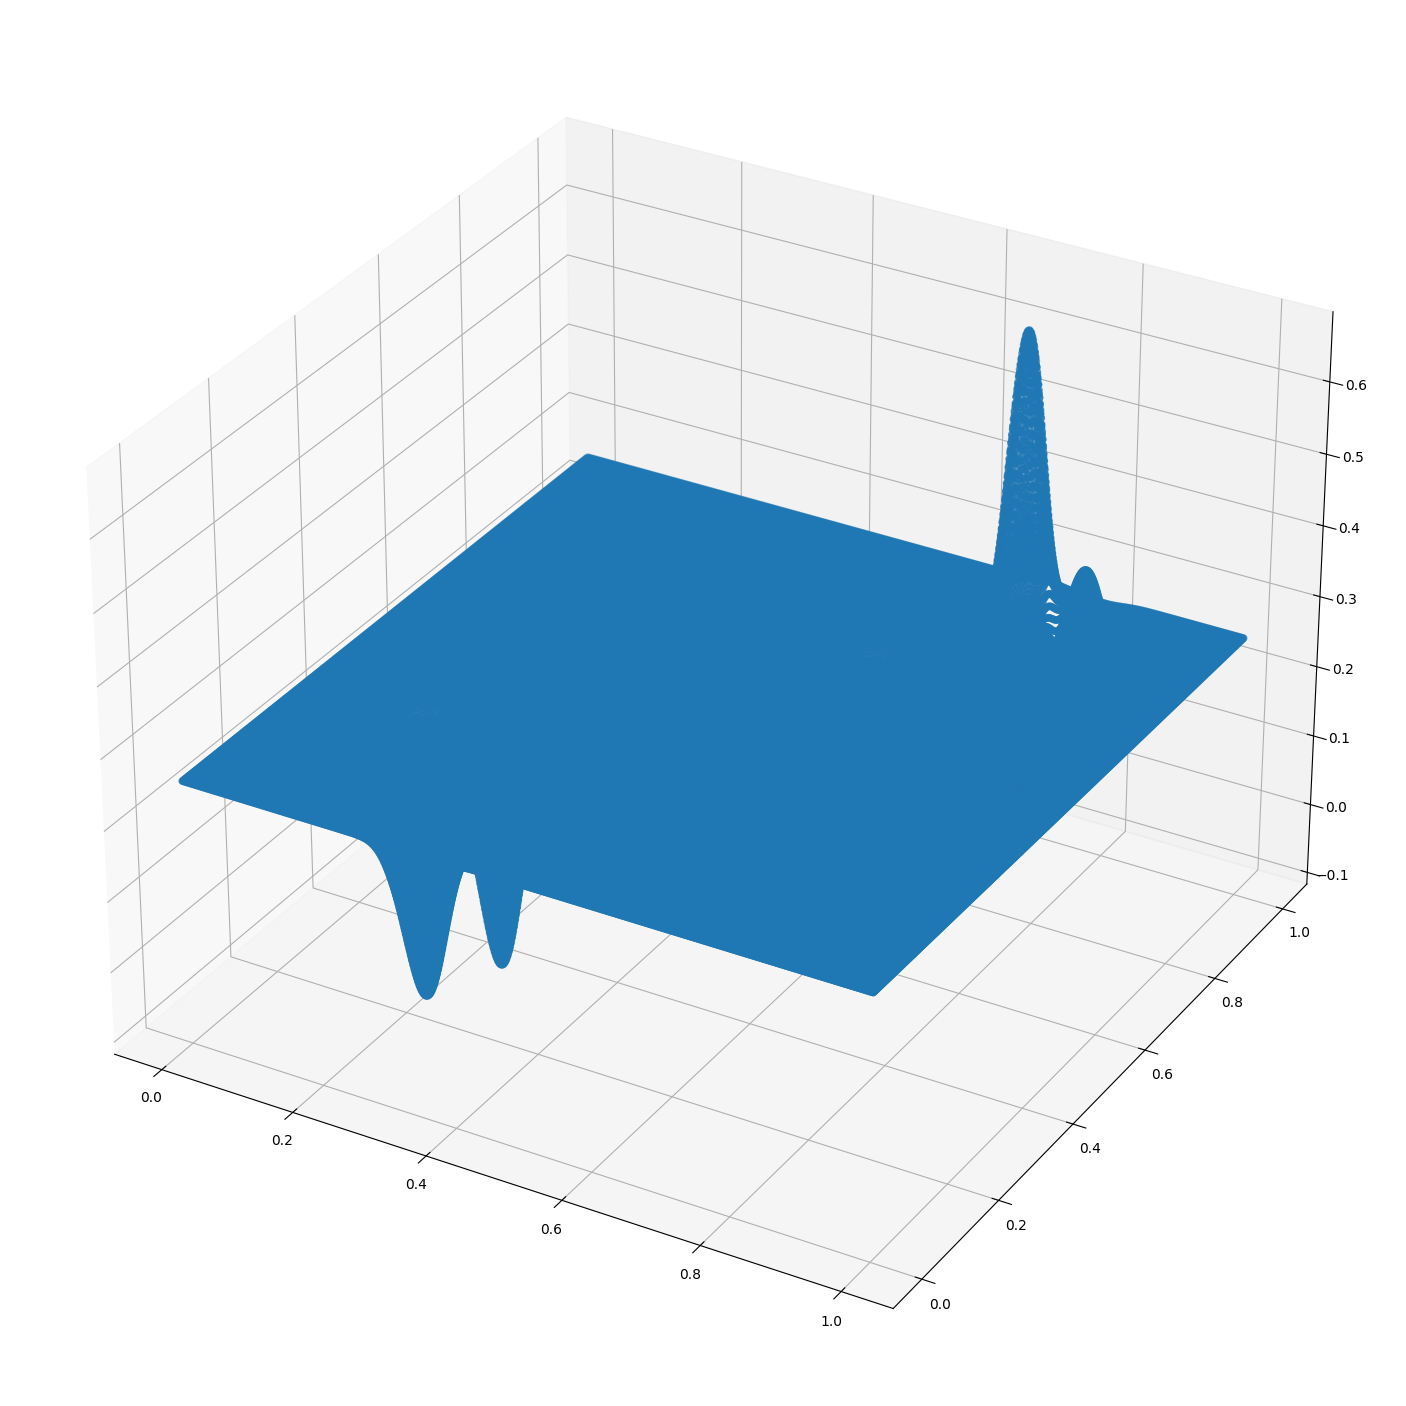

In [13]:
fig = plt.figure(figsize=(20, 18))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_gs, X2_gs, y_mean.reshape(X1_gs.shape))
ax.scatter(next_point_ucb_gs[0], next_point_ucb_gs[1], c="red", s=100, marker="*", label="Next query")

#plt.legend()
plt.show()

## Contour plot - Predicted standard deviation

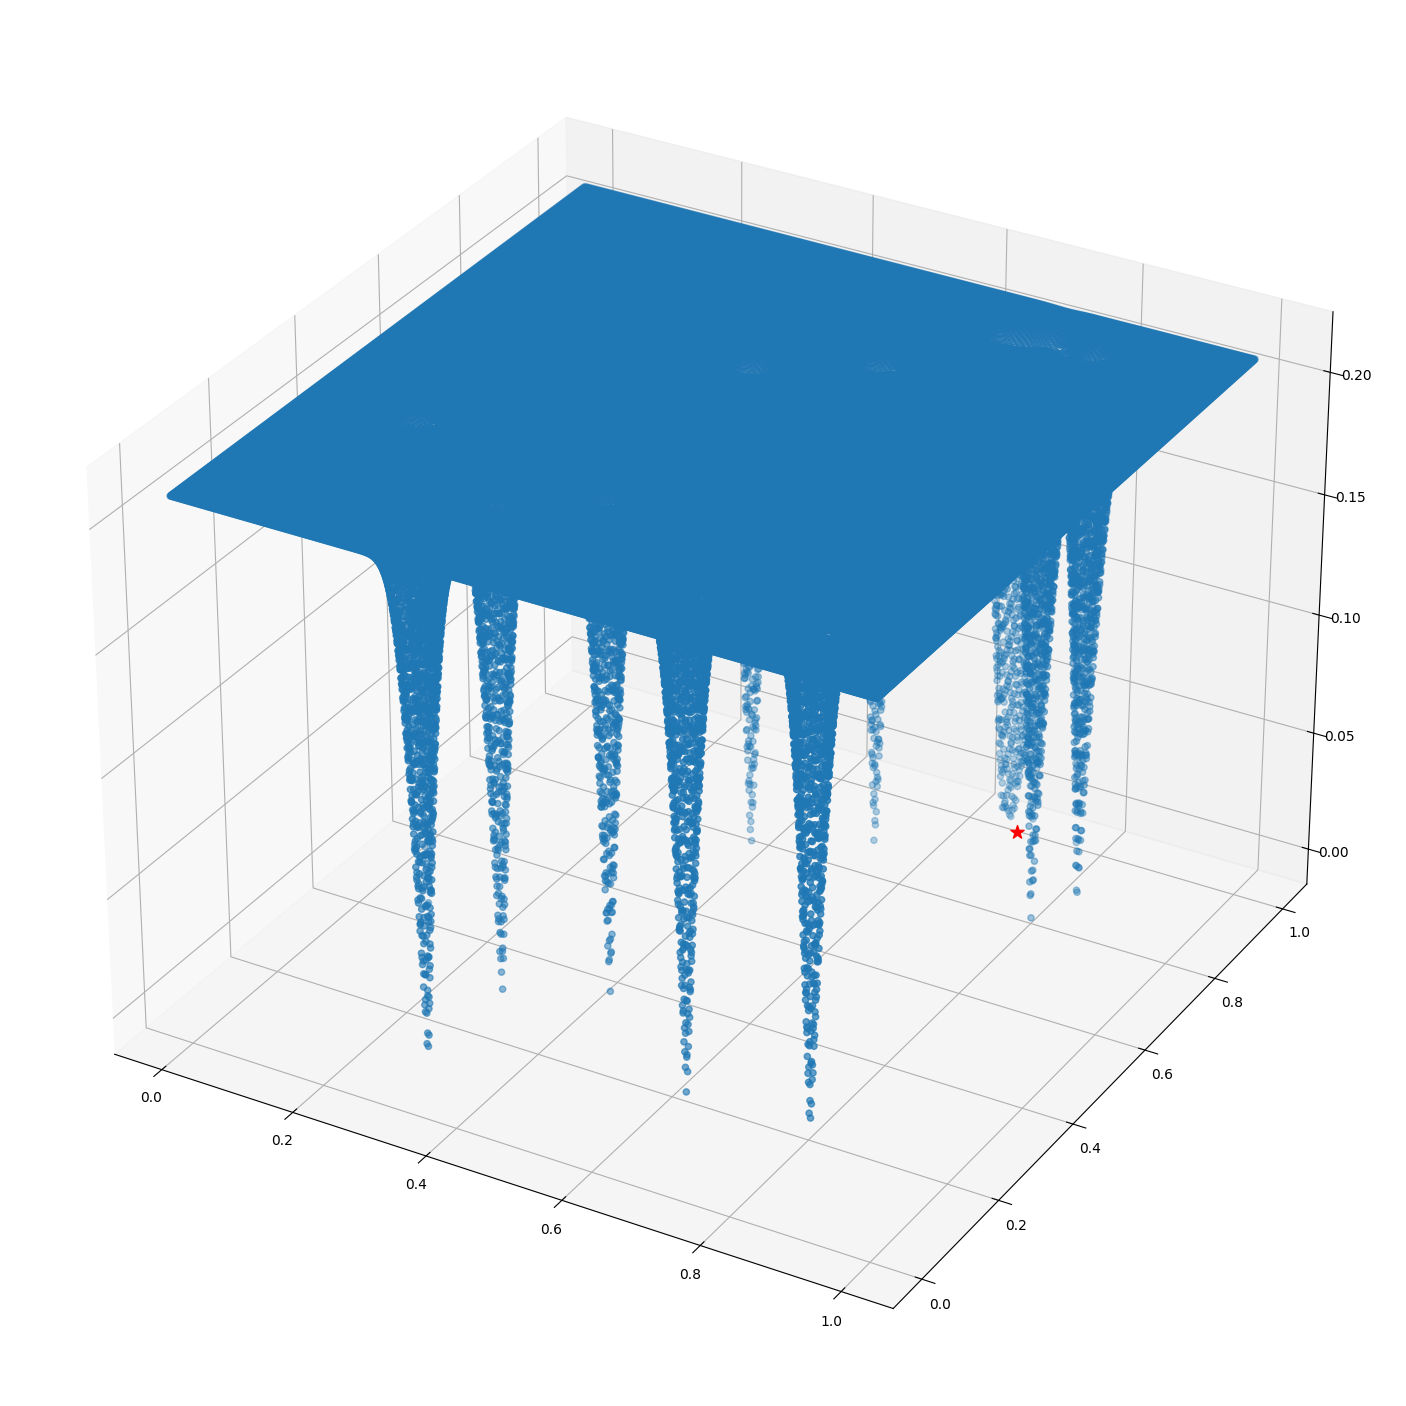

In [14]:
fig = plt.figure(figsize=(20, 18))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_gs, X2_gs, y_std.reshape(X1_gs.shape))
ax.scatter(next_point_ucb_gs[0], next_point_ucb_gs[1], c="red", s=100, marker="*", label="Next query")

#plt.legend()
plt.show()

## Scatter plot - Observations + next query

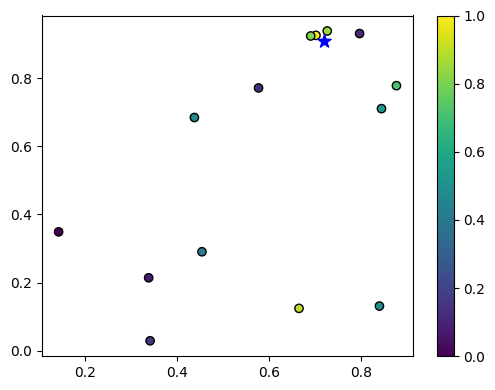

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")
#plt.scatter(next_point[0], next_point[1], c="red", s=100, marker="*", label="Next query")
#plt.scatter(next_point_ucb_gs[0], next_point_ucb_gs[1], c="orange", s=100, marker="*", label="Next query")
plt.scatter(next_point1[0], next_point1[1], c="blue", s=100, marker="*", label="Next query")


plt.colorbar()

plt.tight_layout()
plt.show()